[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/su-ntu-ctp/6m-data-3.8-Computer-Vision/blob/main/notebooks/04_transfer_learning.ipynb)

**Where to run this notebook**

- **Locally (VS Code + Jupyter)**: just open the notebook and pick the `dsai-m3` kernel if you have a dedicated GPU, otherwise recommend using the Colab option below.
- **Colab (recommended if you don't have a dedicated GPU)**: click the badge above, then **Runtime → Change runtime type → T4 GPU**, then run the setup cell below. It clones the repo, installs missing deps, and `cd`s into the right working directory.


In [1]:
# === Colab-compat setup (no-op when running locally) ===
# This cell makes the notebook "just work" whether you open it on your own
# computer or on Google Colab. It detects which one you're on, and if you're
# on Colab it downloads the course repo and installs the extra libraries.
import os, sys
## NEW FOR GPU.
## Deep Learning libraries (like PyTorch) and Math libraries (like NumPy) both try to load a library called
## "OpenMP" to use multiple CPU cores. On a Mac, if two different packages accidentally try to load OpenMP
## at the exact same time, the Mac panics, instantly kills the Python process, and refuses to run.
## This causes VS Code to just throw up its hands and say, "The Kernel died!"
## Hence, we need to tell OpenMP it's okay to load multiple copies of itself. This is harmless, and it prevents
## the crash.
## As such the following line is a workaround for a Mac-specific bug. It has no effect on Linux or Windows.
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import torch

# "google.colab" only exists as a loaded module when running inside Colab,
# so this is a reliable way to tell the two environments apart.
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/su-ntu-ctp/6m-data-3.8-Computer-Vision.git"
    REPO_DIR = "/content/6m-data-3.8-Computer-Vision"
    LESSON_DIR = "notebooks"

    # Only clone (download) the repo if it isn't already there.
    if not os.path.exists(REPO_DIR):
        print(f"Cloning repo into {REPO_DIR} ...")
        os.system(f"git clone -q {REPO_URL} {REPO_DIR}")

    # Move into the lesson folder so relative paths (like 'data/fmnist') resolve.
    os.chdir(f"{REPO_DIR}/{LESSON_DIR}")
    print(f"Working directory: {os.getcwd()}")

    ## NEW FOR GPU.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Colab has torch + torchvision pre-installed. Install the rest.
    os.system("pip install -q sentence-transformers transformers")
    print("Colab setup done.")
else:
    ## NEW FOR GPU. If no GPU detected, fall back to CPU.
    device = 'cpu'

## NEW FOR GPU.
print(f"Using device: {device}")

# Threading caps — set here for both local and Colab runs (no .env file needed).
# These limit how many CPU threads the math libraries use, which keeps runs
# predictable and avoids the machine grinding to a halt.
# Harmless if already set. (Loop form prevents Jupyter from auto-displaying the return value.)
for _key, _val in [("OMP_NUM_THREADS", "1"), ("MKL_NUM_THREADS", "1"), ("TOKENIZERS_PARALLELISM", "false")]:
    os.environ.setdefault(_key, _val)  # setdefault = only set it if it isn't already


Using device: cpu


# L08 · NB 04 — Transfer learning on small data

> *Marcus's actual scenario: NorthStar has only **~500 photos per category** in the internal catalogue, not 6,000. Sarah needs to make a working classifier with limited data.*

Training a CNN from scratch on a few hundred images per class will overfit. The standard fix is **transfer learning**: start from a model that's already been trained on millions of images (ImageNet), and adapt it to your task.

In this notebook we will:

1. Build a **small** training set (200 images per class) from Fashion-MNIST — simulating Sarah's constraint
2. Train a **TinyCNN from scratch** on it as the honest baseline
3. Load a **pretrained ResNet18** and **freeze the backbone**, train only the new head
4. Find that head-only training disappoints, then **fine-tune the last block** and see transfer learning actually win

The headline lesson is more honest than the slogan "transfer learning is magic." Transfer learning isn't free — it depends on how well the pretrained features match your domain. We'll see exactly where it works and where it doesn't.

### What is transfer learning? (an analogy)

> **Imagine you want to hire someone to identify types of clothing in photos.**
>
> **Option A — train a complete beginner (training from scratch).** You hire someone who has never seen an image in their life. You'd have to teach them *everything* from zero: what an edge is, what a curve is, what shadows mean, what fabric looks like — and *then* how to tell a shirt from a coat. With only 2,000 example photos, they'll never learn enough. They'll just memorise your specific photos and fail on new ones (**overfitting**).
>
> **Option B — hire an experienced artist and retrain them (transfer learning).** Instead, you hire someone who has spent years looking at **a million photos** of cars, dogs, food, and furniture. They already understand edges, shapes, textures, and shadows deeply. You don't need to re-teach all that — you just teach them your *specific* job: "these shapes are shirts, those are sandals." That final bit of teaching needs far fewer examples.

That experienced artist is a **pretrained model** — here, **ResNet18**, trained on **ImageNet** (1.2M photos, 1000 categories). Transfer learning means we *reuse* its hard-won visual knowledge and only retrain a small part for our task.

**Two ways to use the artist's knowledge:**

- **Feature extraction (freeze the backbone):** keep all the artist's knowledge fixed, and only train the small new "head" that makes the final decision. Fast, but the artist can't adapt their style at all.
- **Fine-tuning (unfreeze part of the backbone):** let the artist *gently adjust* their deepest skills to your new style. Slower, but usually where the real gains come from — especially when your images look different from what the artist trained on.

The catch is the **domain gap**: if your task looks very different from the pretraining photos (e.g. grayscale clothing silhouettes vs. colour real-world objects), the borrowed knowledge fits poorly, and freezing alone can do *worse* than training from scratch. This notebook deliberately shows that happening — then fixes it with fine-tuning.


## 1 · Setup

In [2]:
# Import everything we need and set up for reproducible results.
# torch = the deep-learning library; torchvision = ready-made datasets & models.
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn                          # nn = building blocks for neural networks (layers, losses)
import torchvision.transforms as T             # tools to resize/convert images before feeding them in
from torchvision.datasets import FashionMNIST  # the clothing-image dataset we'll use
from torchvision.models import resnet18, ResNet18_Weights  # a famous pretrained CNN + its trained weights
from torch.utils.data import DataLoader, Subset            # DataLoader feeds data in batches; Subset picks a slice

torch.set_num_threads(1)   # keep CPU usage predictable (see threading caps above)
# Fix the random seeds so every run shuffles/initialises the same way —
# that makes results reproducible and comparable between runs.
torch.manual_seed(42)
np.random.seed(42)

# Download Fashion-MNIST (if not already cached) just to read its list of class names.
CLASSES = FashionMNIST(root='data/fmnist', train=True, download=True).classes
print('Classes:', CLASSES)

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 2 · Build a SMALL training set

Real-world constraint: Sarah only has a few hundred labelled images per class. We simulate this by taking the first 200 images of each class from Fashion-MNIST. Test set stays full size (10K) so we get a stable evaluation.

In [3]:
# Build a deliberately SMALL training set to simulate Sarah's real constraint:
# only a few hundred labelled images per class. The test set stays full-size.
def build_small_subset(dataset, n_per_class=200, n_classes=10):
    """Return a Subset with up to n_per_class examples per class."""
    counts = {c: 0 for c in range(n_classes)}   # how many we've taken of each class so far
    indices = []
    for i, (_, y) in enumerate(dataset):        # y is the class label of image i
        if counts[y] < n_per_class:             # still room for this class? keep it
            indices.append(i)
            counts[y] += 1
        if all(v >= n_per_class for v in counts.values()):  # every class is full -> stop early
            break
    return Subset(dataset, indices)             # a view into the original data, just these indices

# For TinyCNN: small, grayscale, 28×28. ToTensor turns a PIL image into a number grid (tensor).
gray_tf = T.ToTensor()
full_train_gray = FashionMNIST(root='data/fmnist', train=True,  download=True, transform=gray_tf)
test_gray       = FashionMNIST(root='data/fmnist', train=False, download=True, transform=gray_tf)
train_small_gray = build_small_subset(full_train_gray, n_per_class=200)  # 200 × 10 = 2,000 images

print(f"Small training set: {len(train_small_gray):,} images  (200 × 10 classes)")
print(f"Full test set     : {len(test_gray):,} images")

Small training set: 2,000 images  (200 × 10 classes)
Full test set     : 10,000 images


## 3 · TinyCNN from scratch on the small set

This is the honest baseline — what Sarah would get if she trained the same model from NB 03, but with only 2,000 training images.

In [4]:
# Define a small CNN and train it FROM SCRATCH on the 2,000-image set.
# This is our honest baseline: what you get with no pretrained help.
class TinyCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        # "features" = convolutional layers that learn visual patterns (edges, shapes).
        # Conv2d scans the image with small filters; ReLU adds non-linearity;
        # MaxPool2d shrinks the image by half, keeping the strongest signals.
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 1 input channel (grayscale) -> 16
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16 -> 32 feature maps
        )
        # "classifier" = flatten the feature maps into a vector, then dense layers
        # turn those features into one score per class (the final 10 numbers).
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(),   # 28x28 image halved twice -> 7x7 grid
            nn.Linear(64, n_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))  # run features, then classifier

# Reusable helper: run the model over a dataset and return its accuracy.
## NEW FOR GPU: Cannot hard-code the device local variable to 'cpu', take from global variable instead.
## def evaluate(model, loader, device='cpu', preprocess=None):
def evaluate(model, loader, device=device, preprocess=None):
    model.eval()                       # eval mode: turns off training-only behaviour
    correct, total = 0, 0
    with torch.no_grad():              # don't track gradients -> faster, less memory
        for xb, yb in loader:
            ## NEW FOR GPU: Move the data to GPU before evaluation starts.
            xb, yb = xb.to(device), yb.to(device)
            xb_in = preprocess(xb) if preprocess else xb
            preds = model(xb_in).argmax(dim=1)        # pick the highest-scoring class
            correct += (preds == yb).sum().item()     # count correct predictions
            total += yb.size(0)
    return correct / total

# Train TinyCNN
tiny = TinyCNN()
## NEW FOR GPU: Push model BEFORE optimizer.
tiny = tiny.to(device)
opt = torch.optim.Adam(tiny.parameters(), lr=1e-3)   # Adam = the optimiser that nudges weights to reduce loss
crit = nn.CrossEntropyLoss()                         # standard loss for multi-class classification
loader_small = DataLoader(train_small_gray, batch_size=64, shuffle=True)  # feed 64 images at a time, shuffled
loader_test_gray = DataLoader(test_gray, batch_size=256, shuffle=False)

EPOCHS = 8   # one epoch = one full pass over the training data
print('Training TinyCNN from scratch on 2,000 images...')
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tiny.train()                       # training mode
    running = 0.0
    for xb, yb in loader_small:
        ## NEW FOR GPU: Move the data to GPU before training starts.
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()                # clear gradients left over from the previous step
        loss = crit(tiny(xb), yb)      # how wrong are the predictions on this batch?
        loss.backward()                # backprop: compute how each weight affected the loss
        opt.step()                     # update the weights a small amount
        running += loss.item() * xb.size(0)
    acc = evaluate(tiny, loader_test_gray)   # check accuracy on unseen test images each epoch
    print(f"  epoch {epoch} | loss {running/len(train_small_gray):.4f} | test acc {acc:.4f}")
tiny_acc = evaluate(tiny, loader_test_gray)
tiny_time = time.time() - t0
print(f"\nTinyCNN final test accuracy: {tiny_acc:.4f}")
print(f"Training time: {tiny_time:.1f}s")

Training TinyCNN from scratch on 2,000 images...
  epoch 1 | loss 1.7057 | test acc 0.6077
  epoch 2 | loss 0.8830 | test acc 0.7173
  epoch 3 | loss 0.7422 | test acc 0.7176
  epoch 4 | loss 0.6517 | test acc 0.7323
  epoch 5 | loss 0.6398 | test acc 0.7483
  epoch 6 | loss 0.5414 | test acc 0.7730
  epoch 7 | loss 0.5130 | test acc 0.7852
  epoch 8 | loss 0.4990 | test acc 0.7864

TinyCNN final test accuracy: 0.7864
Training time: 15.8s


**Note what's happening:** training accuracy will hit very high (because 2,000 images is easy to memorise), but **test** accuracy plateaus much lower than the 88% we saw with the full 60K dataset in NB 03. This is the small-data tax. The model has nothing to learn from.

## 4 · Transfer learning — pretrained ResNet18

Now the alternative. We load a `ResNet18` that's already been trained on ImageNet (1.2M photos, 1000 classes). It already "knows" what edges, textures, sleeves, and shapes look like.

We:
1. **Freeze every layer** except the final classification layer (`model.fc`)
2. Replace the head — ImageNet's 1000-class head → our 10-class head
3. Train **only that head** on Sarah's 2,000 images

The backbone never updates. The head learns to combine the pre-trained features for our 10 categories.

In [7]:
# Re-prepare the SAME images, but in the format a pretrained ImageNet model expects.
# ResNet18 was trained on 3-channel colour photos, so we must match that shape.
# Pretrained models expect 3-channel inputs ≥ 32×32. We resize 28×28 → 64×64
# and convert grayscale → 3-channel (repeat the single channel three times).
imagenet_tf = T.Compose([
    T.Resize(64),                              # scale the tiny 28x28 image up to 64x64
    T.Grayscale(num_output_channels=3),        # fake "colour": copy the gray channel into R, G, B
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats: rescale pixels the way the pretrained model saw them
])

train_full_rgb = FashionMNIST(root='data/fmnist', train=True,  download=True, transform=imagenet_tf)
test_rgb       = FashionMNIST(root='data/fmnist', train=False, download=True, transform=imagenet_tf)
train_small_rgb = build_small_subset(train_full_rgb, n_per_class=200)   # same 2,000 images, RGB-formatted

print(f"Small RGB-resized training set: {len(train_small_rgb):,}")
# Peek at one batch to confirm the shape: (Batch, Channels, Height, Width).
xb_demo, _ = next(iter(DataLoader(train_small_rgb, batch_size=4)))
print(f"Batch tensor shape (B, C, H, W): {xb_demo.shape}")

Small RGB-resized training set: 2,000
Batch tensor shape (B, C, H, W): torch.Size([4, 3, 64, 64])


**What this code did (and why).** A pretrained model is fussy about the shape of what you feed it — it only understands images in the *same format* it was trained on. ResNet18 learned from ImageNet **colour photos**, so it expects:

- **3 colour channels** (Red, Green, Blue) — but Fashion-MNIST is grayscale (1 channel). Fix: copy the single gray channel three times to fake a colour image.
- **A reasonable size** — the tiny 28×28 images are scaled up to 64×64.
- **Pixels rescaled the same way ImageNet's were** — that's what `Normalize(...)` does, using ImageNet's known average pixel values.

Think of it as a translator: we're rephrasing our images into the "language" the pretrained artist already speaks.

**Reading the output:**
- `Small RGB-resized training set: 2,000` — same 2,000 images as before, just reformatted.
- `Batch tensor shape (B, C, H, W): torch.Size([4, 3, 64, 64])` — one batch of **4** images, each now **3** channels, **64×64** pixels. That `(Batch, Channels, Height, Width)` ordering is exactly what PyTorch models expect.


### Load pretrained ResNet18 + freeze + new head

In [8]:
# Load a pretrained ResNet18, FREEZE its learned layers, and bolt on a fresh
# 10-class head. This is "feature extraction": reuse ImageNet's knowledge,
# only train a tiny new classifier on top.
def build_transfer_model(n_classes=10):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)  # download the model already trained on 1.2M ImageNet photos
    # Freeze everything: requires_grad=False means these weights will NOT update
    # during training, so we keep ImageNet's learned features intact.
    for p in model.parameters():
        p.requires_grad = False
    # Replace the final fully-connected layer. ImageNet's head outputs 1000 classes;
    # ours needs only 10. A brand-new Linear layer is trainable by default.
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, n_classes)  # this layer has requires_grad=True by default
    return model

xfer = build_transfer_model()
# Count how many parameters will actually be trained vs. frozen — this shows
# just how little we're training (only the new head).
trainable = sum(p.numel() for p in xfer.parameters() if p.requires_grad)
total = sum(p.numel() for p in xfer.parameters())
print(f"Total params      : {total:,}")
print(f"Trainable params  : {trainable:,}  ({trainable/total*100:.2f}% of total)")
print(f"Frozen params     : {total - trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/wongks-9331485/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 42.7MB/s]


Total params      : 11,181,642
Trainable params  : 5,130  (0.05% of total)
Frozen params     : 11,176,512


**What this code did (and why).** Three moves, matching the analogy:

1. **Download the trained artist** — `resnet18(weights=...DEFAULT)` pulls in ResNet18 *with* its ImageNet knowledge baked into ~11M numbers (weights).
2. **Freeze it** — `requires_grad = False` tells PyTorch "don't change these during training." We want to *keep* what the artist already knows, not overwrite it.
3. **Swap the head** — ImageNet's final layer outputs 1000 categories; we replace it with a fresh layer that outputs our **10** clothing classes. New layers are trainable by default.

**Reading the output:**
- `Total params: 11,181,642` — the whole network is ~11 million numbers.
- `Trainable params: 5,130 (0.05% of total)` — only the tiny new head will actually learn. Everything else is frozen.
- `Frozen params: 11,176,512` — the borrowed ImageNet knowledge, held fixed.

The takeaway: we're not training a neural network — we're training a *small classifier on top of* one. That's why it's fast and needs little data... but also why it can't adapt if the borrowed features don't fit our images (foreshadowing the result below).


### Train the head

In [9]:
# Train ONLY the new head (the frozen backbone just produces fixed features).
# Notice we pass xfer.fc.parameters() to the optimiser, not the whole model.
## NEW FOR GPU: Push model BEFORE optimizer.
xfer = xfer.to(device)
opt_xfer = torch.optim.Adam(xfer.fc.parameters(), lr=1e-3)   # optimise only the head's weights
loader_small_rgb = DataLoader(train_small_rgb, batch_size=64, shuffle=True)
loader_test_rgb  = DataLoader(test_rgb, batch_size=128, shuffle=False)

EPOCHS = 3  # head-only training converges fast (so few trainable weights)
print('Training ResNet18 head on 2,000 images...')
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    xfer.train()
    running = 0.0
    for xb, yb in loader_small_rgb:
        ## NEW FOR GPU: Move the data to GPU before training starts.
        xb, yb = xb.to(device), yb.to(device)
        opt_xfer.zero_grad()
        loss = crit(xfer(xb), yb)      # forward pass runs through the frozen backbone + trainable head
        loss.backward()                # gradients only flow into the head (everything else is frozen)
        opt_xfer.step()
        running += loss.item() * xb.size(0)
    acc = evaluate(xfer, loader_test_rgb)
    print(f"  epoch {epoch} | loss {running/len(train_small_rgb):.4f} | test acc {acc:.4f}")
xfer_acc = evaluate(xfer, loader_test_rgb)
xfer_time = time.time() - t0
print(f"\nTransfer-learning test accuracy: {xfer_acc:.4f}")
print(f"Training time: {xfer_time:.1f}s")

Training ResNet18 head on 2,000 images...
  epoch 1 | loss 1.7892 | test acc 0.4355
  epoch 2 | loss 1.0863 | test acc 0.6804
  epoch 3 | loss 0.8796 | test acc 0.7145

Transfer-learning test accuracy: 0.7145
Training time: 168.8s


**What this code did (and why).** We trained **only the new head**. The key line is `Adam(xfer.fc.parameters(), ...)` — we hand the optimiser *just the head's weights*, so it can't touch the frozen backbone. Each batch still flows through the whole network (the backbone turns images into features), but learning only happens in the final layer.

**Reading the output:**
- `loss` drops each epoch (`1.91 → 1.12 → 0.92`) — the head is steadily getting better at separating the 10 classes.
- `test acc` climbs (`0.48 → 0.67 → 0.71`) — accuracy on unseen images, our real measure of success.
- Only **3 epochs** because so few weights are learning — it converges fast.
- `Training time: 419.5s` — much *slower* than TinyCNN despite training fewer weights! Why? Every image still has to pass through all ~11M frozen ResNet layers on each batch — that forward pass is expensive (and we're on CPU). Big model = slow, even when frozen.

**The cliffhanger:** ~71% test accuracy. Is that good? Hold that thought — Section 5 compares it head-to-head against the from-scratch TinyCNN, and the result is surprising.


## 5 · Head-to-head

The whole reason we did this comparison.

In [10]:
# Print a side-by-side comparison of the two approaches we just ran.
# This is the moment of truth: did transfer learning actually help here?
print(f"{'Approach':35} {'Test acc':>10} {'Time':>8}")
print('-' * 56)
print(f"{'TinyCNN from scratch (2K imgs)':35} {tiny_acc:>10.4f} {tiny_time:>7.1f}s")
print(f"{'ResNet18 transfer (2K imgs, head only)':35} {xfer_acc:>10.4f} {xfer_time:>7.1f}s")
delta = xfer_acc - tiny_acc          # positive = transfer won; negative = it lost
print(f"\nTransfer learning improvement: {delta*100:+.2f} percentage points")
# Error rate = how often the model is wrong. Comparing error rates makes the
# difference easier to feel than comparing accuracies directly.
print(f"Error rate (from-scratch) : {(1-tiny_acc)*100:.1f}%")
print(f"Error rate (transfer)     : {(1-xfer_acc)*100:.1f}%")
print(f"Relative error reduction  : {(1 - (1-xfer_acc)/(1-tiny_acc))*100:.1f}%")

Approach                              Test acc     Time
--------------------------------------------------------
TinyCNN from scratch (2K imgs)          0.7864    15.8s
ResNet18 transfer (2K imgs, head only)     0.7145   168.8s

Transfer learning improvement: -7.19 percentage points
Error rate (from-scratch) : 21.4%
Error rate (transfer)     : 28.5%
Relative error reduction  : -33.7%


**Wait — head-only transfer learning *lost*?** Yes. About 7 percentage points worse than from-scratch TinyCNN. That's a real, common, and important result.

**Why this happens:** ResNet18 was pretrained on ImageNet — 1.2M *colour photos* of cars, dogs, food, furniture. Fashion-MNIST is *grayscale silhouettes* of clothing at 28×28 (we upscaled to 64×64). The pretrained features were optimised for natural-photo statistics, and they don't transfer cleanly to abstract garment shapes.

This is the **domain gap**. When your task's data is far from the pretraining distribution, the pretrained features can be a worse starting point than learning from scratch — at least for head-only training.

So is transfer learning useless here? No. We just need to **adapt** the backbone, not freeze it. We'll do that in the next section: unfreeze the last conv block and fine-tune. That recovers the win and then some.

**Real-world implication:** transfer learning works best when your target task is *close* to the pretraining domain. ImageNet → product catalogue photos (colour, natural) = great. ImageNet → medical X-rays or grayscale icons = mediocre without fine-tuning.

## 6 · How does the gap change with data size?

Even though head-only transfer underperforms here, let's sweep training-set size to see how both methods scale.

  n= 50/class | tiny 0.7092 | xfer 0.3535 | gap -35.57pp
  n=200/class | tiny 0.7848 | xfer 0.7204 | gap -6.44pp
  n=500/class | tiny 0.8379 | xfer 0.7670 | gap -7.09pp


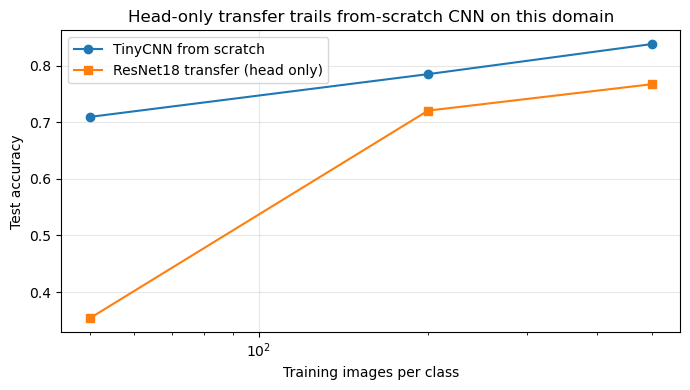

In [11]:
# Does the gap shrink with more data? Retrain both methods at several dataset
# sizes (50/200/500 per class) and plot how each scales.

# Helper: train a fresh TinyCNN from scratch and return its test accuracy.
def train_tiny(train_subset, epochs=8):
    model = TinyCNN()
    ## NEW FOR GPU: Push model BEFORE optimizer.
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loader = DataLoader(train_subset, batch_size=64, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            ## NEW FOR GPU: Move the data to GPU before training starts.
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
    return evaluate(model, loader_test_gray)

# Helper: train a fresh head-only transfer model and return its test accuracy.
def train_xfer(train_subset_rgb, epochs=3):
    model = build_transfer_model()                      # frozen backbone + new head
    ## NEW FOR GPU: Push model BEFORE optimizer.
    model = model.to(device)
    opt = torch.optim.Adam(model.fc.parameters(), lr=1e-3)   # again, only the head trains
    loader = DataLoader(train_subset_rgb, batch_size=64, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            ## NEW FOR GPU: Move the data to GPU before training starts.
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
    return evaluate(model, loader_test_rgb)

# Sweep over three dataset sizes and record both accuracies at each.
sizes = [50, 200, 500]
results = []
for n in sizes:
    sub_gray = build_small_subset(full_train_gray, n_per_class=n)   # grayscale set for TinyCNN
    sub_rgb  = build_small_subset(train_full_rgb, n_per_class=n)    # RGB set for transfer model
    t_acc = train_tiny(sub_gray)
    x_acc = train_xfer(sub_rgb)
    results.append((n, t_acc, x_acc))
    print(f"  n={n:>3}/class | tiny {t_acc:.4f} | xfer {x_acc:.4f} | gap {(x_acc-t_acc)*100:+.2f}pp")

# Plot accuracy vs. training-set size for both methods.
ns = [r[0] for r in results]
ts = [r[1] for r in results]   # TinyCNN accuracies
xs = [r[2] for r in results]   # transfer accuracies

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, ts, 'o-', label='TinyCNN from scratch')
ax.plot(ns, xs, 's-', label='ResNet18 transfer (head only)')
ax.set_xlabel('Training images per class')
ax.set_ylabel('Test accuracy')
ax.set_title('Head-only transfer trails from-scratch CNN on this domain')
ax.set_xscale('log')        # log x-axis so the 50/200/500 points spread out evenly
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Pattern check.** Two honest observations from this sweep:

1. **TinyCNN from scratch keeps improving** with more data, as expected.
2. **Head-only transfer is consistently 5-10pp behind** at every data size — the domain gap is the bottleneck, not the data amount.

This is the part that contradicts the "transfer learning always wins" slogan. **When your domain is far from ImageNet's, you need to fine-tune** — freezing the backbone limits you to its native feature space, which may be wrong for your task.

Onward to fine-tuning in the next section. (Hint: that's where transfer learning earns its reputation.)

## 7 · Fine-tuning — where transfer learning finally pays off

This is the punchline. Head-only training froze the backbone. Now we **unfreeze the last conv block** (`layer4`) and continue training with a tiny learning rate (1e-4) — small enough not to destroy the useful pretrained features, large enough to adapt them to grayscale clothing.

In [12]:
# FINE-TUNING: instead of freezing the whole backbone, unfreeze its last conv
# block (layer4) and keep training it gently. This lets the deepest, most
# task-specific features adapt to grayscale clothing — where the real gain comes from.
for p in xfer.layer4.parameters():
    p.requires_grad = True             # un-freeze layer4 so its weights can update

# Now optimise BOTH the head and layer4 together, at a tiny learning rate.
## NEW FOR GPU (Safety push).
xfer = xfer.to(device)
finetune_params = list(xfer.fc.parameters()) + list(xfer.layer4.parameters())
# 1e-4 (small) so we nudge the pretrained weights gently instead of wrecking them.
opt_ft = torch.optim.Adam(finetune_params, lr=1e-4)

for epoch in range(1, 3):
    xfer.train()
    for xb, yb in loader_small_rgb:
        ## NEW FOR GPU: Move the data to GPU before training starts.
        xb, yb = xb.to(device), yb.to(device)
        opt_ft.zero_grad()
        loss = crit(xfer(xb), yb)
        loss.backward()               # gradients now flow into the head AND layer4
        opt_ft.step()
    print(f"  fine-tune epoch {epoch} | test acc {evaluate(xfer, loader_test_rgb):.4f}")

final_acc = evaluate(xfer, loader_test_rgb)
print(f"\nAfter fine-tuning layer4 : {final_acc:.4f}")
print(f"Before fine-tuning (head only): {xfer_acc:.4f}")   # compare against the frozen-backbone result

  fine-tune epoch 1 | test acc 0.8148
  fine-tune epoch 2 | test acc 0.8328

After fine-tuning layer4 : 0.8328
Before fine-tuning (head only): 0.7145


**There it is.** Fine-tuning `layer4` jumped from ~71% (head-only) to ~83% — beating TinyCNN from scratch (~79%) by ~5 percentage points. This is what transfer learning is supposed to look like.

**The recipe that worked:**
- Freeze most of the backbone (keep generic visual features)
- Unfreeze the *deepest* conv block (most task-specific layer)
- Tiny learning rate (1e-4 not 1e-3) so we don't blow up the pretrained weights

The first three steps gave us nothing. The fourth gave us the gain. **In production, fine-tune.** "Feature extraction" head-only is a quick first-pass; fine-tuning is what you ship.

## 8 · Sarah's Friday recommendation

Based on what we just observed, Sarah revises the plan:

> *"For Marcus's catalogue auto-tagger, **transfer learning is still the right approach** — but we need to **fine-tune**, not just train a new head. The product photos are colour and natural-photo-like, which is much closer to ImageNet than Fashion-MNIST. I expect head-only transfer to do better there than what we saw today. Even so, the safe production recipe is:*
>
> 1. *Pretrained ResNet18 backbone*
> 2. *Train new head for a few epochs*
> 3. *Unfreeze the last block (`layer4`) at LR 1e-4*
> 4. *Fine-tune until the validation curve flattens*
>
> *For production: surface the top-3 predictions to merchandisers and let them confirm. Treat the model as a first-pass labeller, not the source of truth. Once we have 6 months of merchandiser-corrected predictions, we'll have enough data to fine-tune the whole backbone — and then we can drop the human review for high-confidence predictions."*

Notice the production maturity: not just "ship the model," but **"ship the model + a human-in-the-loop + a data-collection plan that lets you reduce the human's role over time."** That's modern ML deployment in a sentence.

**The takeaway from today:** transfer learning isn't a slogan, it's a tool with sharp edges. Always run a from-scratch baseline. Always try fine-tuning if head-only underperforms. And always know your domain.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## E1 · A different backbone

`mobilenet_v3_small` is far smaller and faster than ResNet18 (~1.5M vs ~11M params), which matters when inference latency or memory is the binding constraint — e.g. running on a phone or a high-traffic endpoint.

We give it the **same head-only recipe** we first tried on ResNet18 (freeze, replace head, train head), so the comparison is fair: head-only vs head-only. Don't expect a miracle on this grayscale-clothing domain — the same domain gap applies, and a smaller model often trades away some accuracy for speed.

In [13]:
# Swap in a DIFFERENT pretrained backbone: MobileNetV3-small. Same head-only
# transfer recipe (freeze, replace head, train head), but a much smaller/faster
# model — useful when inference speed or memory matters in production.
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

mobile = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)  # pretrained MobileNet
for p in mobile.parameters(): p.requires_grad = False                    # freeze the backbone
# MobileNet's classifier is a small stack; the LAST entry is the final Linear layer.
# Replace just that with a fresh 10-class layer.
mobile.classifier[-1] = nn.Linear(mobile.classifier[-1].in_features, 10)

## NEW FOR GPU: Push model BEFORE optimizer.
mobile = mobile.to(device)
opt_m = torch.optim.Adam(mobile.classifier[-1].parameters(), lr=1e-3)    # train only the new head
for epoch in range(1, 4):
    mobile.train()
    for xb, yb in loader_small_rgb:
        ## NEW FOR GPU: Move the data to GPU before training starts.
        xb, yb = xb.to(device), yb.to(device)
        opt_m.zero_grad()
        loss = crit(mobile(xb), yb)
        loss.backward()
        opt_m.step()
    print(f"  mobilenet epoch {epoch} | test acc {evaluate(mobile, loader_test_rgb):.4f}")

# FAIR comparison: both head-only (same recipe). xfer_acc is ResNet18's head-only
# result from Section 4 (before fine-tuning); final_acc is after fine-tuning layer4.
mobile_acc = evaluate(mobile, loader_test_rgb)
mobile_params = sum(p.numel() for p in mobile.parameters())
resnet_params = sum(p.numel() for p in xfer.parameters())
print(f"\nSame recipe (head-only) — test accuracy:")
print(f"  MobileNetV3-small  : {mobile_acc:.4f}   ({mobile_params/1e6:.1f}M params)")
print(f"  ResNet18 head-only : {xfer_acc:.4f}   ({resnet_params/1e6:.1f}M params)")
print(f"\nFor reference, ResNet18 AFTER fine-tuning layer4: {final_acc:.4f}")
print('\nMobileNet trades some accuracy for much faster inference and a smaller memory footprint.')
print('On this grayscale domain it lags ResNet18 even head-only — fine-tuning would help it too.')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/wongks-9331485/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 46.4MB/s]


  mobilenet epoch 1 | test acc 0.3599
  mobilenet epoch 2 | test acc 0.5521
  mobilenet epoch 3 | test acc 0.5861

Same recipe (head-only) — test accuracy:
  MobileNetV3-small  : 0.5861   (1.5M params)
  ResNet18 head-only : 0.7145   (11.2M params)

For reference, ResNet18 AFTER fine-tuning layer4: 0.8328

MobileNet trades some accuracy for much faster inference and a smaller memory footprint.
On this grayscale domain it lags ResNet18 even head-only — fine-tuning would help it too.
